# Setup

In [2]:
# Set 1 GPU
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [1]:
!nvidia-smi

Thu Jan  5 05:50:29 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.82.00    Driver Version: 470.82.00    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:0A:00.0 Off |                  N/A |
| 27%   28C    P8    16W / 150W |   1257MiB / 11019MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:41:00.0 Off |                  N/A |
| 27%   

# Clone Vit_Jax - Google Research Repository

In [2]:
!pwd

/home/jovyan/vit


In [3]:
# Clone repository and pull latest changes.
![ -d vision_transformer ] || git clone --depth=1 https://github.com/google-research/vision_transformer
!cd vision_transformer && git pull

Already up to date.


In [3]:
!pip install -qr vision_transformer/vit_jax/requirements.txt

In [4]:
# Shows all available pre-trained models.
!gsutil ls -lh gs://vit_models/imagenet*
!gsutil ls -lh gs://vit_models/sam
!gsutil ls -lh gs://mixer_models/*

/bin/bash: gsutil: command not found
/bin/bash: gsutil: command not found
/bin/bash: gsutil: command not found


# Import Library

In [8]:
from absl import logging
import flax
import jax
from matplotlib import pyplot as plt
import numpy as np
import optax
import tqdm
from glob import glob
import jax.numpy as jnp

logging.set_verbosity(logging.INFO)

# Shows the number of available devices.
# In a CPU/GPU runtime this will be a single device.
# In a TPU runtime this will be 8 cores.
jax.local_devices()

[StreamExecutorGpuDevice(id=0, process_index=0),
 StreamExecutorGpuDevice(id=1, process_index=0)]

In [7]:
# Import files from repository.

import sys
if './vision_transformer' not in sys.path:
  sys.path.append('./vision_transformer')

%load_ext autoreload
%autoreload 2

from vit_jax import checkpoint
from vit_jax import input_pipeline
from vit_jax import utils
from vit_jax import models
from vit_jax import train
from vit_jax.configs import common as common_config
from vit_jax.configs import models as models_config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# import tensorflow as tf
# tf.config.experimental.set_visible_devices([], "GPU")

# Load Data

In [4]:
# import zipfile

# zip_ref = zipfile.ZipFile("vit/ball_dataset.zip", 'r')
# zip_ref.extractall("ball_dataset")
# zip_ref.close()

In [11]:
dataset = 'cifar10'
config = common_config.with_dataset(common_config.get_config(), dataset)
num_classes = len(glob('/home/jovyan/vit/ball_dataset/train/*'))        # 30 Class
batch_size = 32
config.batch = batch_size
config.batch_eval = batch_size
config.pp.crop = 224
print(config)

accum_steps: 8
base_lr: 0.03
batch: 32
batch_eval: 32
checkpoint_every: 1000
dataset: cifar10
decay_type: cosine
eval_every: 100
grad_norm_clip: 1.0
model: null
model_or_filename: null
optim_dtype: bfloat16
pp:
  crop: 224
  test: test
  train: train[:98%]
prefetch: 2
pretrained_dir: .
progress_every: 10
shuffle_buffer: 50000
tfds_data_dir: null
tfds_manual_dir: null
total_steps: 10000
trainer: train
warmup_steps: 500



In [12]:
# For details about setting up datasets, see input_pipeline.py on the right.
ds_train = input_pipeline.get_data_from_directory(config=config,directory='/home/jovyan/vit/ball_dataset/train' ,mode='train')
ds_test = input_pipeline.get_data_from_directory(config=config, directory='/home/jovyan/vit/ball_dataset/test', mode='test')

del config  # Only needed to instantiate datasets.

In [13]:
from glob import glob
num_train_images = len(glob('/home/jovyan/vit/ball_dataset/train/*/*'))
num_validation_images  = len(glob('/home/jovyan/vit/ball_dataset/valid/*/*'))
num_test_images  = len(glob('/home/jovyan/vit/ball_dataset/test/*/*'))

print("Train:", num_train_images)
print("Test:", num_test_images)
print("Valid:", num_validation_images)

Train: 3615
Test: 150
Valid: 150


In [14]:
labelnames = dict(cifar10=("baseball", "basketball", "beachballs", "billiard ball", "bowling_ball", 
                           "brass", "buckeyballs", "cannon_ball", "chrochet_ball", "cricket_ball", 
                           "crystal_ball", "eyeballs", "football", "golf_ball", "marble", "meat_ball",
                           "medicine_ball", "paint_balls", "pokeman_balls", "puffballs", "rubberband_ball",
                           "screwballs", "sepak_takraw_ball", "soccer_ball", "tennis_ball", "tether_ball", 
                           "volley_ball", "water_polo_ball", "wiffle_ball", "wrecking_ball"))

def make_label_getter(dataset):
  """Returns a function converting label indices to names."""
  def getter(label):
    if dataset in labelnames:
      return labelnames[dataset][label]
    return f'label={label}'
  return getter

def show_img(img, ax=None, title=None):
  """Shows a single image."""
  if ax is None:
    ax = plt.gca()
  ax.imshow(img[...])
  ax.set_xticks([])
  ax.set_yticks([])
  if title:
    ax.set_title(title)

def show_img_grid(imgs, titles):
  """Shows a grid of images."""
  n = int(np.ceil(len(imgs)**.5))
  _, axs = plt.subplots(n, n, figsize=(3 * n, 3 * n))
  for i, (img, title) in enumerate(zip(imgs, titles)):
    img = (img + 1) / 2  # Denormalize
    show_img(img, axs[i // n][i % n], title)

In [15]:
ds_test.take(10)

<TakeDataset element_spec={'image': TensorSpec(shape=(2, 16, 224, 224, 3), dtype=tf.float32, name=None), 'label': TensorSpec(shape=(2, 16, 30), dtype=tf.float32, name=None)}>

In [16]:
# Fetch a batch of test images for illustration purposes.
batch_test = next(ds_test.as_numpy_iterator())
# Note the shape : [num_local_devices, local_batch_size, h, w, c]
batch_test['image'].shape

(2, 16, 224, 224, 3)

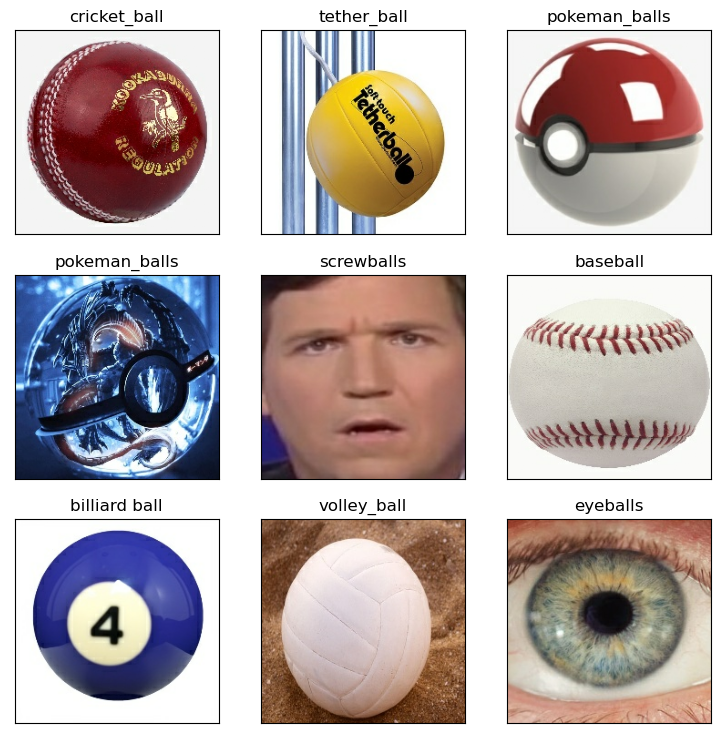

In [17]:
# Show some imags with their labels.
images, labels = batch_test['image'][0][:9], batch_test['label'][0][:9]
titles = map(make_label_getter(dataset), labels.argmax(axis=1))
show_img_grid(images, titles)

In [18]:
batch_train = next(iter(ds_train.as_numpy_iterator()))
batch_train['image'].shape

(2, 16, 224, 224, 3)

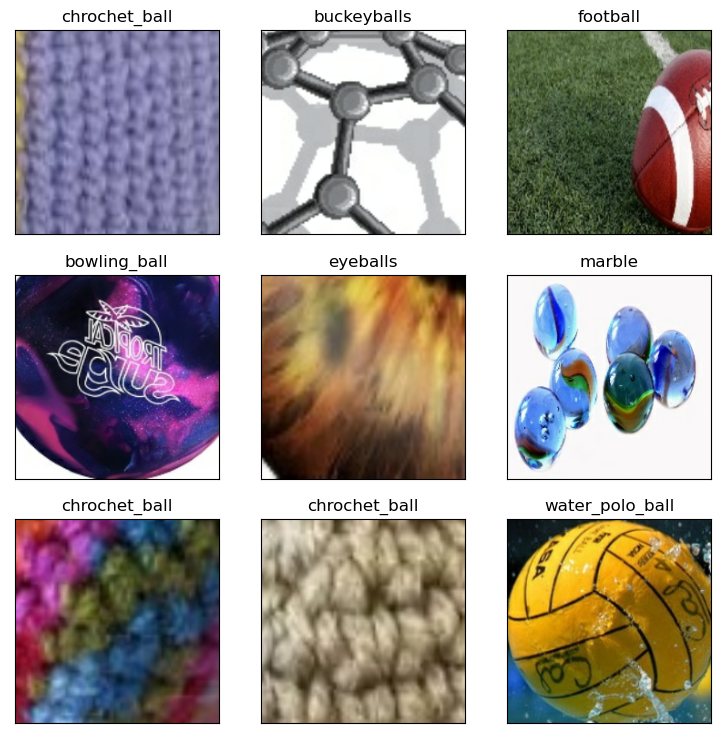

In [19]:
images, labels = batch_train['image'][0][:9], batch_train['label'][0][:9]
titles = map(make_label_getter(dataset), labels.argmax(axis=1))
show_img_grid(images, titles)

# Training Model

In [20]:
# Download a pre-trained model.

model_name = 'ViT-B_32' 
![ -e "$model_name".npz ] || gsutil cp gs://vit_models/imagenet21k/"$model_name".npz .

import os
assert os.path.exists(f'{model_name}.npz')

In [21]:
model_config = models_config.MODEL_CONFIGS[model_name]
model_config

classifier: token
hidden_size: 768
model_name: ViT-B_32
patches:
  size: !!python/tuple
  - 32
  - 32
representation_size: null
transformer:
  attention_dropout_rate: 0.0
  dropout_rate: 0.0
  mlp_dim: 3072
  num_heads: 12
  num_layers: 12

In [22]:
# Load model definition & initialize random parameters.
model = models.VisionTransformer(num_classes=num_classes, **model_config)
variables = jax.jit(lambda: model.init(
    jax.random.PRNGKey(0),
    # Discard the "num_local_devices" dimension of the batch for initialization.
    batch_train['image'][0, :1],
    train=False,
), backend='cpu')()


# Then map the call to our model's forward pass onto all available devices.
vit_apply_repl = jax.pmap(lambda params, inputs: model.apply(dict(params=params), inputs, train=False))

In [23]:

def fit(total_steps, data, grad_norm_clip, accum_steps):
    
    losses = []
    
    # Load and convert pretrained checkpoint.
    # This involves loading the actual pre-trained model results, but then also also
    # modifying the parameters a bit, e.g. changing the final layers, and resizing
    # the positional embeddings.
    params = checkpoint.load_pretrained(
        pretrained_path=f'{model_name}.npz',
        init_params=variables['params'],
        model_config=model_config,
    )

    params_repl = flax.jax_utils.replicate(params) 

    # We use a momentum optimizer that uses half precision for state to save
    # memory. It als implements the gradient clipping.
    tx = optax.chain(
        optax.clip_by_global_norm(grad_norm_clip),
        optax.sgd(
            learning_rate=lr_fn,
            momentum=0.9,
            accumulator_dtype='bfloat16',
        ),
    )
    
     # Update step for data parallel training
    update_fn_repl = train.make_update_fn(apply_fn=model.apply, accum_steps=accum_steps, tx=tx)

    # Momentum optimizer that stores state using half-precision
    opt_state = tx.init(params)
    # opt

    # Replicating optimizer across devices
    opt_state_repl = flax.jax_utils.replicate(opt_state)
    # opt_repl

    # Initialize PRNGs for dropout.
    update_rng_repl  = flax.jax_utils.replicate(jax.random.PRNGKey(0))     
    
    
    #--------------------------------------------------------------------------------

        
    for step, batch in zip(tqdm.trange(1, total_steps + 1), data.as_numpy_iterator()):
        params_repl, opt_state_repl, loss_repl, update_rng_repl = update_fn_repl(params_repl,
                                                                                 opt_state_repl,
                                                                                 batch,
                                                                                 update_rng_repl)
        losses.append(loss_repl[0])
        
    plt.plot(losses)
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Training Loss")
        

    return (params_repl, opt_state_repl)

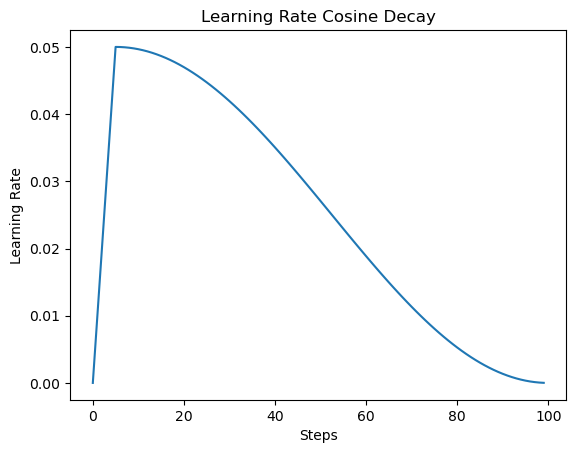

In [24]:
total_steps = 100     # total training steps 
base_lr = 0.05        # Base learning rate 
wormup_steps = 5      # Warmup steps for learning_rate_scheduler
grad_norm_clip = 1    # Glips gradient norm 
accum_steps = 8       # Controls in how many forward passes the batch is split (8 for TPU)
decay_type = 'cosine'

lr_fn = utils.create_learning_rate_schedule(total_steps, base_lr, decay_type, wormup_steps)

plot_lr = []
for step in range(total_steps):
    plot_lr.append(lr_fn(step).item())
plt.plot(plot_lr)
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Cosine Decay");

In [ ]:
params_repl, opt_state_repl = fit(total_steps = total_steps,
                                  data = ds_train,
                                 grad_norm_clip = grad_norm_clip,
                                 accum_steps = accum_steps)

INFO:absl:Inspect extra keys:
{'pre_logits/bias', 'pre_logits/kernel'}
INFO:absl:load_pretrained: drop-head variant
  0%|          | 0/100 [00:00<?, ?it/s]

# Evaluate

In [29]:
def evaluate(params, dataset, image_count , batch_size):
    total = 0 
    correct = 0 
    steps =  image_count // batch_size
    preds = jnp.array([])
    true_labels = jnp.array([])
    for _, batch in zip(tqdm.trange(steps), dataset.as_numpy_iterator()):
        prediction = vit_apply_repl(params, batch['image'])                      
        batch_prediction = prediction.argmax(axis=-1).reshape(batch_size )
        batch_true = batch['label'].argmax(axis=-1).reshape(batch_size )
        preds = jnp.append(preds,batch_prediction)
        true_labels = jnp.append(true_labels,batch_true)
        preds_bool = prediction.argmax(axis=-1) == batch['label'].argmax(axis=-1) 
        correct += preds_bool.sum()
        total += len(preds_bool.flatten())
    accuracy = correct / total
    return accuracy, preds , true_labels


batch_size = 32
valid_acc_jnp, valid_preds_jnp, valid_true_jnp = evaluate(
    params_repl,  
    ds_test , 
    num_test_images , 
    batch_size
)

val_acc = valid_acc_jnp.item()*100
print(f"\n Accuracy = {val_acc:.2f}%")

100%|██████████| 4/4 [00:00<00:00, 18.03it/s]


 Accuracy = 100.00%


In [23]:
CLASSES = ["baseball", "basketball", "beachballs", "billiard ball", "bowling_ball", 
           "brass", "buckeyballs", "cannon_ball", "chrochet_ball", "cricket_ball", 
           "crystal_ball", "eyeballs", "football", "golf_ball", "marble", "meat_ball",
           "medicine_ball", "paint_balls", "pokeman_balls", "puffballs", "rubberband_ball",
           "screwballs", "sepak_takraw_ball", "soccer_ball", "tennis_ball", "tether_ball", 
           "volley_ball", "water_polo_ball", "wiffle_ball", "wrecking_ball"]

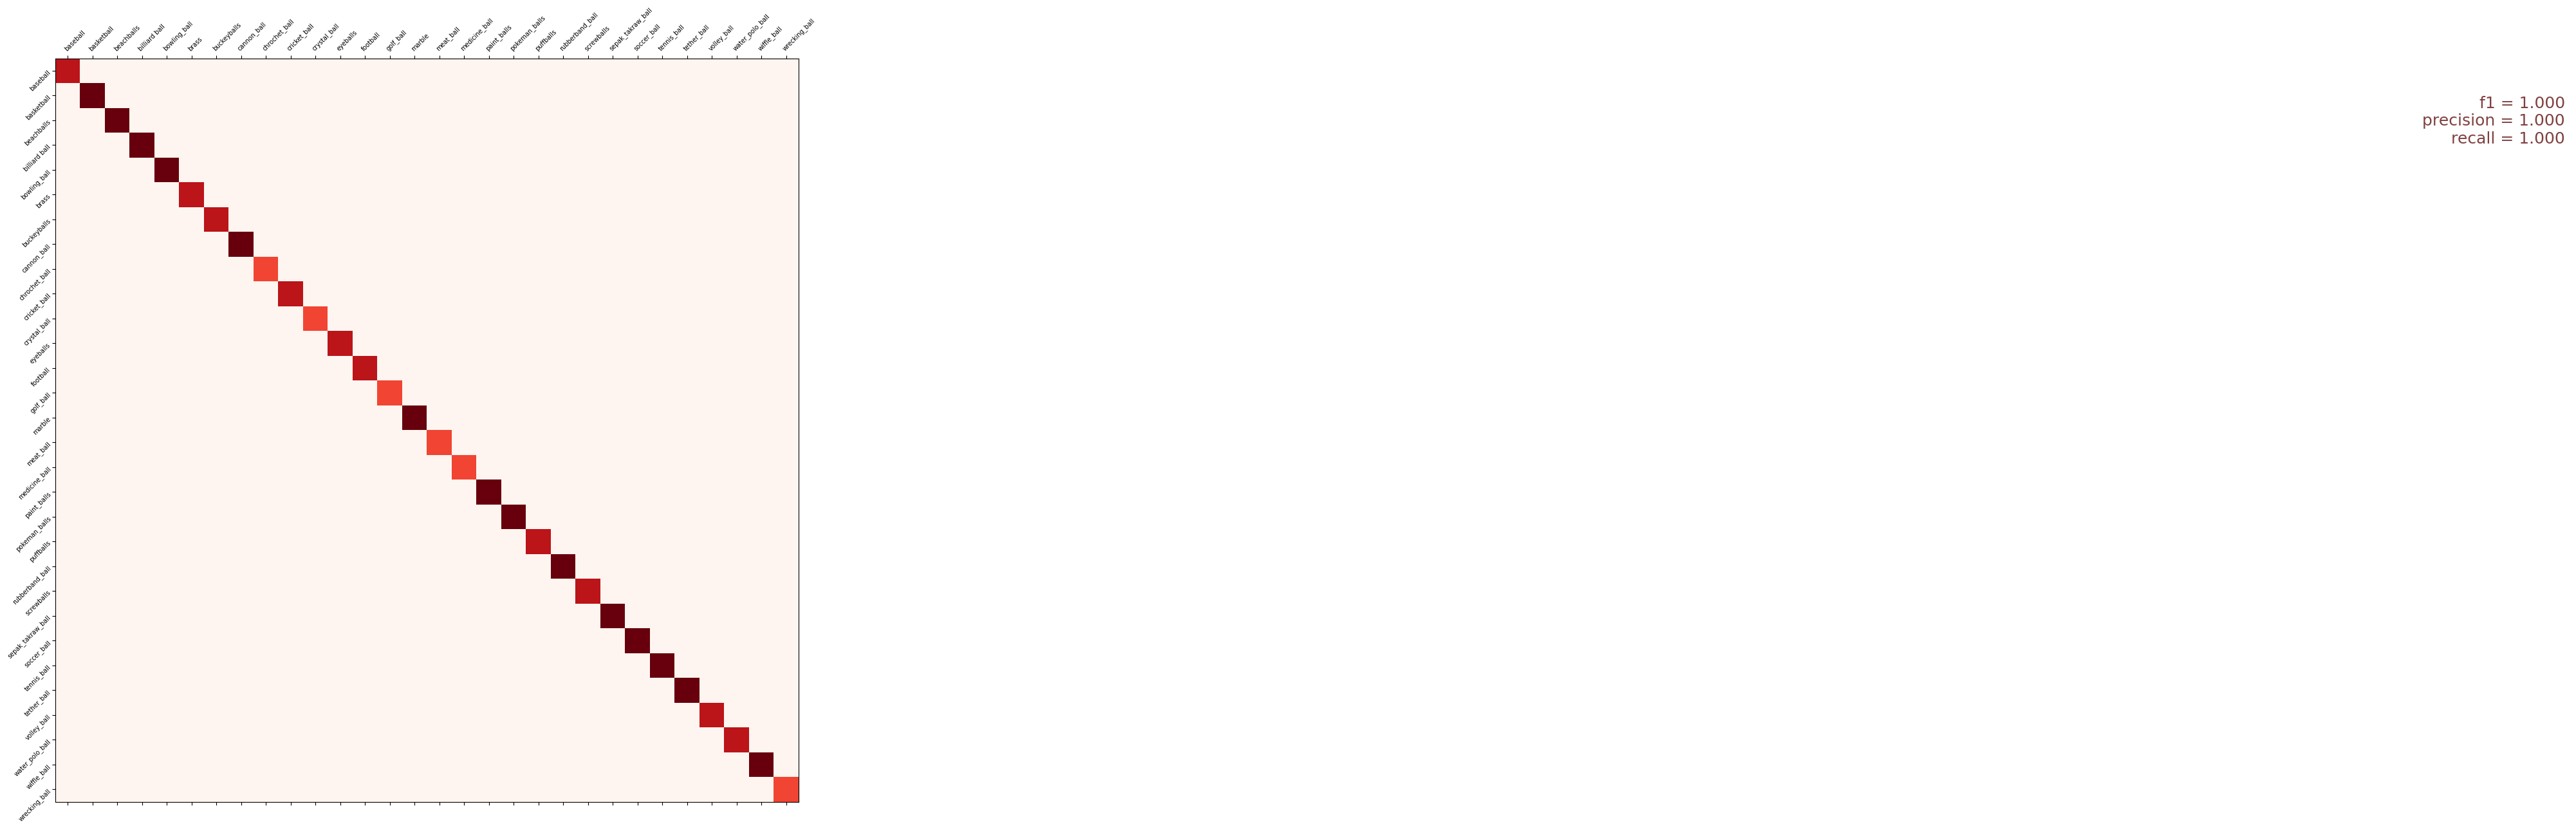

In [24]:
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score 
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix

def display_confusion_matrix(cmat, score, precision, recall):
    """
    Plots Confusion Matrix 
    """
    plt.figure(figsize=(15,15))
    ax = plt.gca()
    ax.matshow(cmat, cmap='Reds')
    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, fontdict={'fontsize': 7})
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")
    ax.set_yticks(range(len(CLASSES)))
    ax.set_yticklabels(CLASSES, fontdict={'fontsize': 7})
    plt.setp(ax.get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    titlestring = ""
    if score is not None:
        titlestring += 'f1 = {:.3f} '.format(score)
    if precision is not None:
        titlestring += '\nprecision = {:.3f} '.format(precision)
    if recall is not None:
        titlestring += '\nrecall = {:.3f} '.format(recall)
    if len(titlestring) > 0:
        ax.text(101, 1, titlestring, 
                fontdict={
                    'fontsize': 18, 
                    'horizontalalignment':'right',
                    'verticalalignment':'top', 
                    'color':'#804040'})
    plt.show()
    
y_true = valid_true_jnp.astype("int32")
y_preds = valid_preds_jnp.astype("int32")

labels = range(len(CLASSES))
cmat = confusion_matrix(y_true, y_preds, labels= labels)
score = f1_score(y_true, y_preds, labels=labels, average='macro')
precision = precision_score(y_true, y_preds, labels=labels, average='macro')
recall = recall_score(y_true, y_preds, labels=labels, average='macro')
display_confusion_matrix(cmat,score,precision,recall)